In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

pd.set_option("display.max_columns", None)

In [2]:
model_results = pd.read_csv("../../05_outputs/model_results/model_comparison.csv")

model_results

,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.802842,0.455307,0.857895,0.594891,0.893747
1,Decision Tree,0.972469,0.895522,0.947368,0.920716,0.962466
2,Random Forest V1,0.975133,0.965517,0.884211,0.923077,0.998251
3,Random Forest V2,0.973357,0.976190,0.863158,0.916201,0.998406


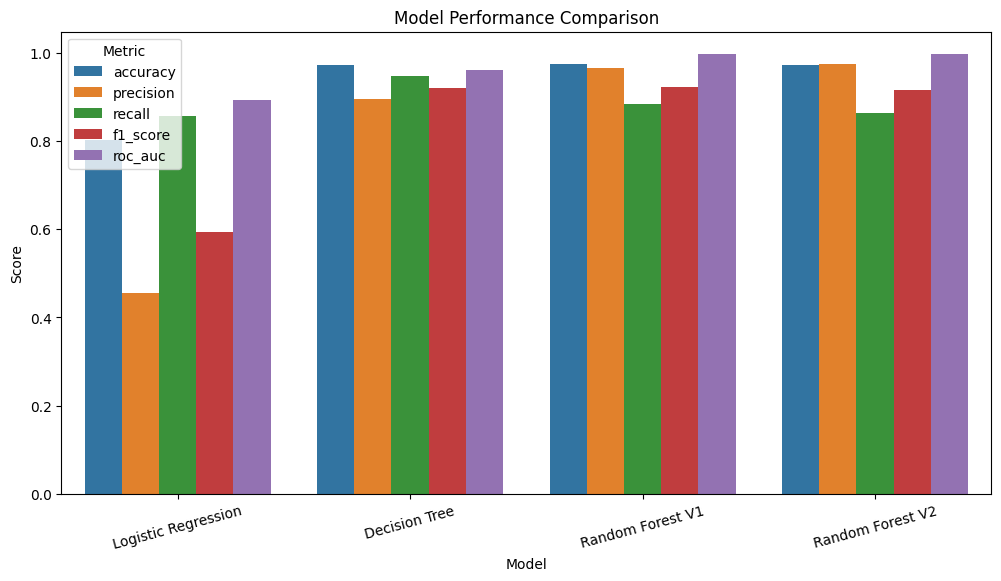

In [3]:
model_results_melted = model_results.melt(
    id_vars="model",
    value_vars=["accuracy", "precision", "recall", "f1_score", "roc_auc"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=model_results_melted,
    x="model",
    y="score",
    hue="metric"
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.legend(title="Metric")
plt.show()

In [4]:
model_results.sort_values("f1_score", ascending=False)

,model,accuracy,precision,recall,f1_score,roc_auc
2,Random Forest V1,0.975133,0.965517,0.884211,0.923077,0.998251
1,Decision Tree,0.972469,0.895522,0.947368,0.920716,0.962466
3,Random Forest V2,0.973357,0.976190,0.863158,0.916201,0.998406
0,Logistic Regression,0.802842,0.455307,0.857895,0.594891,0.893747


In [5]:
model_results.sort_values("recall", ascending=False)

,model,accuracy,precision,recall,f1_score,roc_auc
1,Decision Tree,0.972469,0.895522,0.947368,0.920716,0.962466
2,Random Forest V1,0.975133,0.965517,0.884211,0.923077,0.998251
3,Random Forest V2,0.973357,0.976190,0.863158,0.916201,0.998406
0,Logistic Regression,0.802842,0.455307,0.857895,0.594891,0.893747


In [6]:
model_results.sort_values("roc_auc", ascending=False)

,model,accuracy,precision,recall,f1_score,roc_auc
3,Random Forest V2,0.973357,0.976190,0.863158,0.916201,0.998406
2,Random Forest V1,0.975133,0.965517,0.884211,0.923077,0.998251
1,Decision Tree,0.972469,0.895522,0.947368,0.920716,0.962466
0,Logistic Regression,0.802842,0.455307,0.857895,0.594891,0.893747


In [7]:
selected_model = joblib.load("../../06_models/random_forest_churn_model.pkl")

selected_model

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [8]:
import sys

sys.path.append(os.path.abspath("../preprocessing"))

from preprocess_churn import load_and_prepare_data

data = load_and_prepare_data()

X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]

In [9]:
feature_names = selected_model.named_steps["preprocessor"].get_feature_names_out()

rf_importances = selected_model.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_importances
}).sort_values("importance", ascending=False)

feature_importance_df.head(20)

,feature,importance
0,num__tenure,0.196949
17,num__is_new_customer,0.090530
12,num__cashback_amount,0.067741
2,num__warehouse_to_home,0.054726
11,num__day_since_last_order,0.051275
6,num__number_of_address,0.049771
8,num__order_amount_hike_from_last_year,0.042763
5,num__satisfaction_score,0.039183
19,num__has_complaint,0.037227
7,num__complain,0.036942


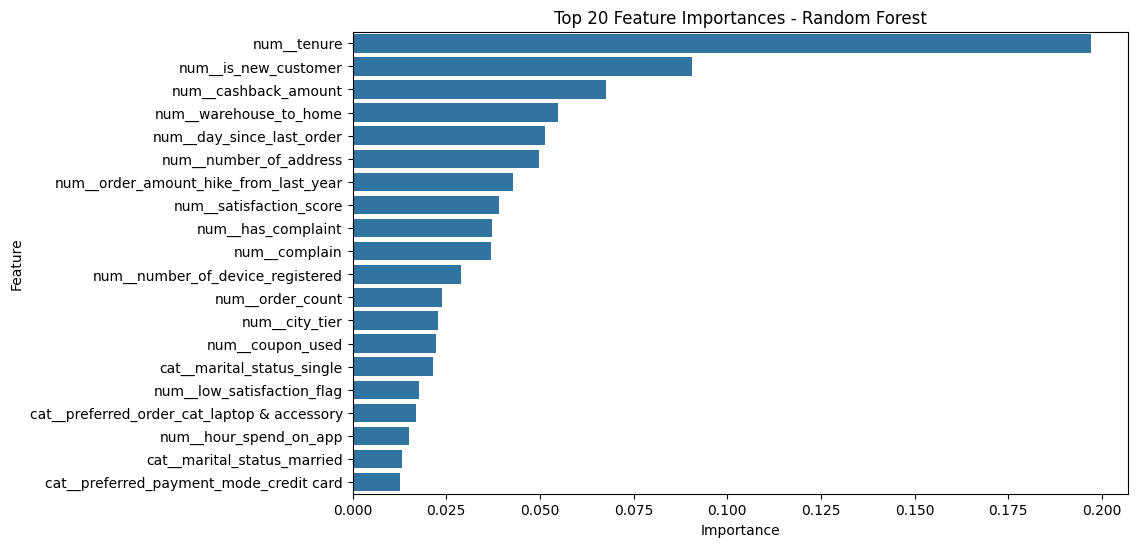

In [10]:
top_features = feature_importance_df.head(20)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_features,
    x="importance",
    y="feature"
)

plt.title("Top 20 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [11]:
os.makedirs("../../05_outputs/model_results", exist_ok=True)

feature_importance_df.to_csv(
    "../../05_outputs/model_results/random_forest_feature_importance.csv",
    index=False
)

In [12]:
os.path.exists("../../05_outputs/model_results/random_forest_feature_importance.csv")

True

## Model Evaluation Summary

Four models were evaluated: Logistic Regression, Decision Tree, Random Forest V1, and Random Forest V2.

Logistic Regression was used as the baseline model. It achieved good recall but low precision, meaning it could detect many churned customers but also produced many false positives.

Decision Tree achieved the highest recall, which means it captured the largest share of actual churned customers. However, a single decision tree may be less stable and more prone to overfitting.

Random Forest V1 achieved the best overall balance. It had the highest F1-score, very high precision, strong recall, and very high ROC-AUC. Therefore, Random Forest V1 was selected as the main model.

Random Forest V2 was trained after removing two potentially redundant engineered features: `is_new_customer` and `has_complaint`. Its performance remained strong, which suggests that the model is not fully dependent on those engineered flags.

The feature importance analysis shows that `tenure`, `is_new_customer`, `cashback_amount`, `warehouse_to_home`, `day_since_last_order`, and complaint-related variables are among the most important predictors of churn.